## 번역가는 대화에도 능하다 [챗봇 프로젝트 보고서]
목표: 트랜스포머 아키텍처를 활용하여 맥락이 통하고 단어 반복이 없는 인간다운 대화 모델 구축

1. 프로젝트 과정
- 데이터셋 선정 및 전처리: 데이터 누수를 방지하기 위해 증강 작업 전 학습 데이터와 테스트 데이터를 9:1로 분리했습니다. 학습 데이터에만 Word2Vec 기반 단어 교체 및 노이즈 추가를 적용하여 약 4.6만 개의 데이터를 확보했습니다.

- 모델 아키텍처 설계: 초기에는 4계층(n_layers=4), 임베딩 512차원의 무거운 모델을 설계했으나, 1만 개 규모의 데이터셋에 맞춰 과적합을 방지하고자 2계층(n_layers=2), 256차원의 경량화된 트랜스포머 구조로 최종 확정했습니다.

- 학습 전략 수립: 총 50 에포크(Epoch)를 설정하고, 전체 스텝의 5% 구간 동안 학습률을 서서히 높이는 동적 웜업(Warmup) 스케줄러를 적용하여 초반 학습 안정성을 확보했습니다.

- 성능 모니터링: 학습 시 검증 데이터(Validation)를 별도로 두어 손실(Loss)과 정확도(Accuracy)를 시각화했습니다. 또한 학습 종료 후 Gemini 모델과의 답변 비교표를 만들어 정성적인 품질을 점검했습니다.

2. 프로젝트 문제점과 개선방안
- 초기 손실값 폭발(Logit Explosion) 해결: 학습 초기 손실값이 5000 이상으로 치솟는 문제가 발생했습니다. 이는 Pre-LayerNorm 구조에서 최종 출력 직전 정규화가 누락되어 발생한 것으로, 인코더와 디코더 출구에 Final LayerNorm을 추가하여 손실값을 20대 수준으로 안정화했습니다.

- 무한 반복되는 '앵무새 현상' 억제: "아니 네요. 아니 네요."와 같은 단어 반복 문제를 해결하기 위해, 추론 단계에서 이미 생성된 토큰에 벌점을 주는 '반복 페널티(Repetition Penalty 1.2)'와 'Top-p 샘플링(0.9)', 'Temperature(0.7)' 기법을 도입하여 대화의 자연스러움을 높였습니다.

- 과대적합(Overfitting) 제어: 학습 데이터 정확도는 80%에 육박하나 검증 데이터는 50%대에 머무는 과대적합 현상이 관찰되었습니다. 이를 해결하기 위해 가중치 규제(Weight Decay 0.01)를 적용하고 드롭아웃을 조절하여 모델의 일반화 성능을 개선했습니다.

3. 주요 성과 및 평가
- 정량적 지표: 가중치 규제 적용 후 BERTScore가 0.84 수준(오늘 진짜 춥다 질문 기준)까지 상승하며 문장 구성 능력이 눈에 띄게 좋아졌습니다.

- 정성적 지표: 단순한 키워드 매칭을 넘어 "밥 먹고 맛있게 드세요", "감기 조심하세요"와 같이 문맥에 맞는 자연스러운 한국어 구사가 가능해졌음을 확인했습니다.

4. 향후 계획  
- RLHF 도입: 제미나이의 공감 점수를 보상 신호로 활용하여 모델이 더 따뜻한 대답을 하도록 스스로 학습하는 강화학습 구조를 설계할 계획입니다.

- 오답 노트 학습: 제미나이 평가에서 낮은 점수를 받은 '논리적 오류' 문장들을 선별하여 사람이 직접 교정한 고품질 데이터로 미세 조정(Fine-tuning)을 진행할 예정입니다. 

### 회고  
처음에는 모델의 층을 깊게 쌓고 파라미터를 키우는 것이 정답이라 생각했으나, 데이터의 규모에 맞는 모델의 '체급'을 결정하는 것이 훨씬 중요하다는 것을 깨달았습니다. 특히 손실값 폭발 문제를 해결하며 트랜스포머의 수치적 안정성을 깊이 이해하게 되었고, 디코딩 전략(Penalty, Top-p 등) 한 줄이 모델의 답변 품질을 얼마나 극적으로 바꾸는지 직접 체감할 수 있었던 뜻깊은 프로젝트였습니다.

In [1]:
# !mkdir -p ~/work/transformer_chatbot/data/spa-eng

# # 환경 변수 설정
# %env CXXFLAGS=-std=c++11 -w

# # 패키지 설치
# !pip install --upgrade pip
# !pip install konlpy sentencepiece nltk gensim google-genai mecab-python3 bert_score

# # MeCab 스크립트 실행 (엔진 설치 확인용)
# !bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

In [2]:
import os, re, random, math
import pickle
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import gensim
from konlpy.tag import Mecab

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [3]:
# 하이퍼파라미터 세팅
BATCH_SIZE = 64
EPOCHS = 50     # 더 깊은 모델은 수렴에 시간이 더 걸릴 수 있습니다.    

n_layers = 2      # 복잡한 문맥 파악을 위해 한 층 더 쌓습니다.
d_model = 256     # 표준적인 크기 (8로 나누어 떨어짐)
n_heads = 8
d_ff = 1024       # d_model의 4배
dropout = 0.4 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Step 1. 데이터 다운로드

In [4]:
# import urllib.request
# # songys/Chatbot_data 데이터를 다운로드합니다. 
# urllib.request.urlretrieve("https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv", filename="ChatbotData.csv")

In [5]:
train_data = pd.read_csv('ChatbotData.csv')

questions = train_data['Q'].tolist()
answers = train_data['A'].tolist()
print(f"전체 샘플 수: {len(questions)}")

전체 샘플 수: 11823


### Step 2. 데이터 정제

In [6]:
# 영문자 소문자 변환 및 영문, 한글, 숫자, 주요 특수문자를 제외한 나머지 제거
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    # 영문자, 한글, 숫자, 주요 특수문자(.,?!)를 제외하곤 모두 제거
    sentence = re.sub(r"[^a-z가-힣0-9.,?!]+", " ", sentence)
    sentence = sentence.strip() # 문자열 양 끝 공백 제거
    return sentence

### Step 3. 데이터 토큰화

In [7]:
mecab = Mecab()

def build_corpus(src_data, tgt_data, mecab, max_len=40):
    src_corpus, tgt_corpus = [], []
    # 질문과 답변을 묶어서(Tuple) 중복을 체크하는 set 하나만 사용
    seen_pairs = set()
    
    for src, tgt in tqdm(zip(src_data, tgt_data), total=len(src_data)):
        src_clean = preprocess_sentence(src)
        tgt_clean = preprocess_sentence(tgt)
        
        # 1. 토큰화 전 원문 쌍으로 중복 체크 (또는 토큰화 후 체크 가능)
        pair = (src_clean, tgt_clean)
        
        if pair not in seen_pairs:
            src_tokens = mecab.morphs(src_clean)
            tgt_tokens = mecab.morphs(tgt_clean)
            
            # 2. 길이 필터링
            if len(src_tokens) <= max_len and len(tgt_tokens) <= max_len:
                seen_pairs.add(pair)
                src_corpus.append(src_tokens)
                tgt_corpus.append(tgt_tokens)
                
    return src_corpus, tgt_corpus

que_corpus, ans_corpus = build_corpus(questions, answers, mecab)
print(f"중복 및 길이 필터링 후 샘플 수: {len(que_corpus)}")

100%|██████████| 11823/11823 [00:00<00:00, 16648.89it/s]

중복 및 길이 필터링 후 샘플 수: 11749


In [8]:
q_train, q_val, a_train, a_val = train_test_split(
    que_corpus, ans_corpus, test_size=0.1, random_state=42
)
print(f"Train 샘플 수: {len(q_train)}, Val 샘플 수: {len(q_val)}")

Train 샘플 수: 10574, Val 샘플 수: 1175


### Step 4. Augmentation

In [9]:
# 1. Lexical Substitution 함수
def lexical_sub(tokens, wv_model):
    wv = wv_model.wv if hasattr(wv_model, 'wv') else wv_model
    vocab = wv.key_to_index if hasattr(wv, 'key_to_index') else wv.vocab
    valid_tokens = [tok for tok in tokens if tok in vocab]
    
    if not valid_tokens: return tokens
    selected_tok = random.choice(valid_tokens)
    try:
        similar_word = wv.most_similar(selected_tok)[0][0]
        return [similar_word if tok == selected_tok else tok for tok in tokens]
    except: return tokens

# 2. Noise 추가 함수 (10% 삭제, 10% <unk> 치환)
def add_noise(tokens, blank_token="<unk>"): 
    if len(tokens) <= 1: return tokens
    
    new_tokens = []
    for tok in tokens:
        r = random.random()
        if r < 0.10: # 10% 확률로 삭제
            continue
        elif r < 0.20: # 10% 확률로 <unk>로 치환
            new_tokens.append(blank_token)
        else:
            new_tokens.append(tok)
            
    # 모든 단어가 삭제되는 불상사 방지
    return new_tokens if len(new_tokens) > 0 else tokens

In [10]:
# 저장할 파일 경로 설정
que_file = "aug_que_train.pkl"
ans_file = "aug_ans_train.pkl"

# 파일이 이미 존재하는지 확인
if os.path.exists(que_file) and os.path.exists(ans_file):
    print("이미 증강된 데이터 파일이 존재합니다. 파일을 불러옵니다...")
    with open(que_file, "rb") as f:
        aug_que_train = pickle.load(f)
    with open(ans_file, "rb") as f:
        aug_ans_train = pickle.load(f)
else:
    print("증강된 데이터가 없습니다. Augmentation을 시작합니다...")
    
    # Word2Vec 모델 로드
    word2vec = gensim.models.Word2Vec.load('./word2vec/word2vec_ko.model')

    aug_que_train, aug_ans_train = [], []

    for q_tok, a_tok in tqdm(zip(q_train, a_train), total=len(q_train)):
        # [Case 1] 원본
        aug_que_train.append(q_tok)
        aug_ans_train.append(a_tok)
        # [Case 2] 질문 Lexical
        if random.random() < 0.5:
            aug_que_train.append(lexical_sub(q_tok, word2vec))
            aug_ans_train.append(a_tok)
        # [Case 3] 답변 Lexical
        if random.random() < 0.5:
            aug_que_train.append(q_tok)
            aug_ans_train.append(lexical_sub(a_tok, word2vec))
        # [Case 4] Noise 2번
        aug_que_train.append(add_noise(q_tok))
        aug_ans_train.append(a_tok)
        aug_que_train.append(add_noise(q_tok))
        aug_ans_train.append(a_tok)

    # 결과 저장 
    with open(que_file, "wb") as f:
        pickle.dump(aug_que_train, f)
    with open(ans_file, "wb") as f:
        pickle.dump(aug_ans_train, f)
    print("증강 및 저장이 완료되었습니다.")

print(f"최종 데이터 샘플 수: {len(aug_que_train)}") 
# 기댓값: 10,574 * (1 + 0.5 + 0.5 + 2) = 약 42,296개

이미 증강된 데이터 파일이 존재합니다. 파일을 불러옵니다...
최종 데이터 샘플 수: 42309


### Step 5. 데이터 벡터화

In [11]:
# 타겟 데이터에 특수 토큰 추가 (Train & Test 모두)
aug_ans_train = [["<start>"] + ans + ["<end>"] for ans in aug_ans_train]
a_val = [["<start>"] + ans + ["<end>"] for ans in a_val]

# 단어 사전 구축 (Train 기준)
all_tokens = [tok for seq in aug_que_train + aug_ans_train for tok in seq]
vocab = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
for tok in all_tokens:
    if tok not in vocab: vocab[tok] = len(vocab)
VOCAB_SIZE = len(vocab)
print(f"단어 사전 크기: {VOCAB_SIZE}")

단어 사전 크기: 7598


In [12]:
# 토큰을 ID로 변환
def tensorize(corpus, vocab, max_len=50):
    tensor = []
    for seq in corpus:
        ids = [vocab.get(tok, vocab["<unk>"]) for tok in seq]
        if len(ids) > max_len:
            ids = ids[:max_len]
        else:
            ids = ids + [vocab["<pad>"]] * (max_len - len(ids))
        tensor.append(ids)
    return torch.tensor(tensor, dtype=torch.long)

enc_train = tensorize(aug_que_train, vocab, max_len=40)
dec_train = tensorize(aug_ans_train, vocab, max_len=40)
enc_val = tensorize(q_val, vocab, max_len=40)
dec_val = tensorize(a_val, vocab, max_len=40)

In [13]:
# DataLoader 생성
train_dataloader = DataLoader(TensorDataset(enc_train, dec_train), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataloader = DataLoader(TensorDataset(enc_val, dec_val), batch_size=BATCH_SIZE, shuffle=False)

In [14]:
# 1. 보캅 크기 및 특수 토큰 확인
print(f"전체 보캅 크기: {len(vocab)}")
print(f"특수 토큰 확인: <pad>:{vocab.get('<pad>')}, <start>:{vocab.get('<start>')}, <end>:{vocab.get('<end>')}, <unk>:{vocab.get('<unk>')}")

# 2. 빈도수가 높은 상위 20개 단어 확인 (사전 구축 시 빈도순으로 넣었다면)
# 만약 단순 dict라면 아래 코드로 실제 말뭉치 빈도를 확인해보세요.
from collections import Counter
all_tokens = [tok for seq in aug_que_train for tok in seq]
counts = Counter(all_tokens)
print("\n가장 많이 등장하는 형태소 TOP 10:", counts.most_common(10))

# 3. 데이터 Coverage(커버리지) 확인
# 훈련 데이터 중 <unk>로 변환되는 비율이 얼마나 되는지 체크합니다.
def check_unk_ratio(corpus, vocab):
    total_tokens = 0
    unk_count = 0
    for tokens in corpus:
        for tok in tokens:
            total_tokens += 1
            if tok not in vocab:
                unk_count += 1
    return (unk_count / total_tokens) * 100

unk_ratio = check_unk_ratio(aug_que_train, vocab)
print(f"\n질문 데이터 내 <unk> 비율: {unk_ratio:.2f}%") # 1~2% 미만이면 매우 우수함

# 4. 실제 인코딩/디코딩 샘플 확인
sample_idx = 0
sample_tokens = aug_que_train[sample_idx]
sample_ids = [vocab.get(t, vocab['<unk>']) for t in sample_tokens]
reverse_vocab = {v: k for k, v in vocab.items()}
decoded = [reverse_vocab.get(i) for i in sample_ids]

print(f"\n원본 토큰: {sample_tokens}")
print(f"인코딩 IDs: {sample_ids}")
print(f"디코딩 결과: {decoded}")

전체 보캅 크기: 7598
특수 토큰 확인: <pad>:0, <start>:1, <end>:2, <unk>:3

가장 많이 등장하는 형태소 TOP 10: [('<unk>', 15111), ('는', 7561), ('이', 7196), ('.', 7048), ('하', 6997), ('어', 6358), ('?', 5526), ('가', 5406), ('고', 4554), ('아', 4400)]

질문 데이터 내 <unk> 비율: 0.00%

원본 토큰: ['라면', '잘', '끓이', '는', '법']
인코딩 IDs: [4, 5, 6, 7, 8]
디코딩 결과: ['라면', '잘', '끓이', '는', '법']


### model

In [15]:
import numpy as np

# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table

In [16]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

In [17]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

In [18]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

In [19]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

In [20]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

In [21]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout) 
        
        # 인코더 최종 출구를 위한 LayerNorm
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
            
        # 모든 층을 통과한 후 마지막으로 정규화
        out = self.norm(out)
        
        return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)

In [22]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        
        #디코더 최종 출구를 위한 LayerNorm
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
            
        # [모든 층을 통과한 후 마지막으로 정규화
        out = self.norm(out)
        
        return out, dec_attns, dec_enc_attns

In [23]:
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

### train

In [24]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=1000, start_lr=1e-6, peak_lr=1e-3): 
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.start_lr = start_lr
        self.peak_lr = peak_lr

    def __call__(self, step):
        step = float(step)
        
        if step <= self.warmup_steps:
            # 1. 웜업 구간 (Step 1 ~ warmup_steps)
            # start_lr(예: 1e-6)에서 시작해서 peak_lr(예: 1e-3)까지 선형적으로(직선으로) 쭉 증가합니다.
            return self.start_lr + (self.peak_lr - self.start_lr) * (step / self.warmup_steps)
        else:
            # 2. 감소 구간 (warmup_steps 이후 ~ 끝까지)
            # 최고점을 찍은 이후부터는 트랜스포머 고유의 역제곱근 비율로 서서히 감소합니다.
            return self.peak_lr * ((step / self.warmup_steps) ** -0.5)

In [25]:
def loss_function(real, pred, smoothing=0.2):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(
        pred.contiguous().view(-1, pred.size(-1)), 
        real.contiguous().view(-1), 
        reduction='none',
        label_smoothing=smoothing 
    )
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

### Step 6. 훈련하기

In [26]:
transformer = Transformer(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=dropout,
    shared_fc=True,
    shared_emb=True
).to(device)


In [27]:
# Accuracy 계산 함수 추가
def calculate_accuracy(real, pred):
    mask = (real != 0).float()
    corrects = (pred.argmax(dim=-1) == real).float()
    acc = (corrects * mask).sum() / mask.sum()
    return acc

In [28]:
def train(model, train_dataloader, val_dataloader, epochs, device, save_dir="checkpoints"):
    os.makedirs(save_dir, exist_ok=True)
    
    total_step = epochs * len(train_dataloader)
    warmup_steps = total_step * 0.05
    learning_rate_scheduler = LearningRateScheduler(model.d_model, warmup_steps=warmup_steps)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=learning_rate_scheduler(1), 
        betas=(0.9, 0.98), eps=1e-9, weight_decay=0.05  
    )
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    global_step = 1 
    
    for epoch in range(epochs):
        # ---------- 1. Train Loop ----------
        model.train() 
        train_loss, train_acc = 0.0, 0.0
        train_count = len(train_dataloader)
        
        tqdm_bar = tqdm(total=train_count, desc=f"Epoch {epoch+1} Train")
        
        for src, tgt in train_dataloader:
            optimizer.zero_grad()
            
            tgt_in = tgt[:, :-1]
            gold = tgt[:, 1:]
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
            
            src, tgt_in, gold = src.to(device), tgt_in.to(device), gold.to(device)
            enc_mask, dec_enc_mask, dec_mask = enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device)
            
            predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
            
            loss = loss_function(gold, predictions)
            acc = calculate_accuracy(gold, predictions)
            
            loss.backward()
            optimizer.step()
            
            global_step += 1
            new_lr = learning_rate_scheduler(global_step)
            for param_group in optimizer.param_groups:
                param_group['lr'] = new_lr
            
            train_loss += loss.item()
            train_acc += acc.item()
            
            tqdm_bar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{acc.item():.4f}"})
            tqdm_bar.update(1)
        tqdm_bar.close()
        
        avg_train_loss = train_loss / train_count
        avg_train_acc = train_acc / train_count
        
        # ---------- 2. Validation Loop ----------
        model.eval()
        val_loss, val_acc = 0.0, 0.0
        val_count = len(val_dataloader)
        
        with torch.no_grad():
            for src, tgt in val_dataloader:
                tgt_in = tgt[:, :-1]
                gold = tgt[:, 1:]
                enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
                
                src, tgt_in, gold = src.to(device), tgt_in.to(device), gold.to(device)
                enc_mask, dec_enc_mask, dec_mask = enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device)
                
                predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
                loss = loss_function(gold, predictions)
                acc = calculate_accuracy(gold, predictions)
                
                val_loss += loss.item()
                val_acc += acc.item()
                
        avg_val_loss = val_loss / val_count
        avg_val_acc = val_acc / val_count
        
        # 히스토리 저장
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)
        history['lr'].append(new_lr)
        
        print(f"Epoch {epoch+1} 완료 - Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f} | Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")
        
        # 모델 저장 (Validation Loss 기준)
        if avg_val_loss < best_val_loss:
            best_path = os.path.join(save_dir, "best_transformer.pt")
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), best_path)
            
    return history

In [29]:
history = train(transformer, train_dataloader, val_dataloader, EPOCHS, device)

Epoch 1 Train: 100%|██████████| 662/662 [00:24<00:00, 26.68it/s, Loss=15.6847, Acc=0.1818] 


Epoch 1 완료 - Train Loss: 71.7464, Train Acc: 0.0597 | Val Loss: 11.2419, Val Acc: 0.2285


Epoch 2 Train: 100%|██████████| 662/662 [00:24<00:00, 26.59it/s, Loss=7.4118, Acc=0.3095] 


Epoch 2 완료 - Train Loss: 11.2165, Train Acc: 0.1936 | Val Loss: 6.3197, Val Acc: 0.2943


Epoch 3 Train: 100%|██████████| 662/662 [00:25<00:00, 25.68it/s, Loss=5.2333, Acc=0.4390]


...

Epoch 48 완료 - Train Loss: 3.7027, Train Acc: 0.6294 | Val Loss: 4.4884, Val Acc: 0.5308


Epoch 49 Train: 100%|██████████| 662/662 [00:25<00:00, 26.22it/s, Loss=3.6031, Acc=0.6667]


Epoch 49 완료 - Train Loss: 3.6875, Train Acc: 0.6328 | Val Loss: 4.4872, Val Acc: 0.5320


Epoch 50 Train: 100%|██████████| 662/662 [00:25<00:00, 26.23it/s, Loss=3.6768, Acc=0.6250]


Epoch 50 완료 - Train Loss: 3.6714, Train Acc: 0.6364 | Val Loss: 4.4922, Val Acc: 0.5305


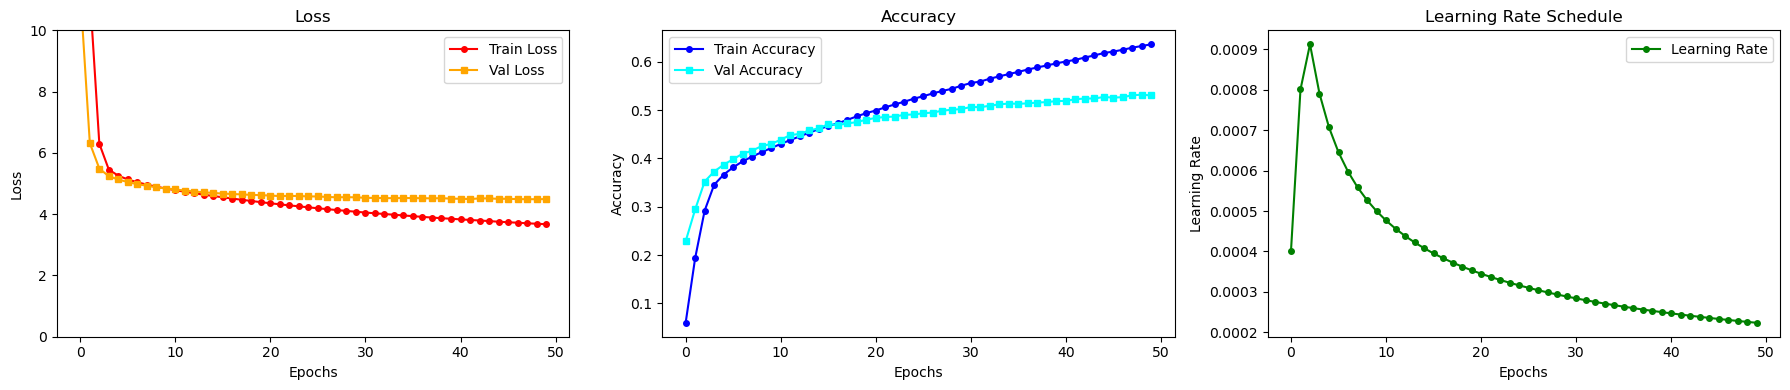

In [30]:
plt.figure(figsize=(18, 4))

# 1. Loss 그래프
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss', color='red', marker='o', markersize=4)
plt.plot(history['val_loss'], label='Val Loss', color='orange', marker='s', markersize=4)
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, 10)
plt.legend()

# 2. Accuracy 그래프
plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue', marker='o', markersize=4)
plt.plot(history['val_acc'], label='Val Accuracy', color='cyan', marker='s', markersize=4)
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 3. Learning Rate 그래프
plt.subplot(1, 3, 3)
plt.plot(history['lr'], label='Learning Rate', color='green', marker='o', markersize=4)
plt.title('Learning Rate Schedule')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.legend()

plt.tight_layout()
plt.show()

### Step 7. 성능 측정하기

In [42]:
import pandas as pd
import re
from google import genai
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score

In [43]:
# 1. 훈련 때와 동일한 설정으로 빈 모델 껍데기 생성
model = Transformer(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=dropout,
    shared_fc=True,
    shared_emb=True
).to(device)

# 2. 저장된 가중치(Best Acc) 불러와서 덮어씌우기
model.load_state_dict(torch.load(f"checkpoints/best_transformer.pt"))
model.eval()

Transformer(
  (enc_emb): Embedding(7598, 256)
  (dec_emb): Embedding(7598, 256)
  (do): Dropout(p=0.4, inplace=False)
  (encoder): Encoder(
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (enc_self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=256, out_features=256, bias=True)
          (W_k): Linear(in_features=256, out_features=256, bias=True)
          (W_v): Linear(in_features=256, out_features=256, bias=True)
          (linear): Linear(in_features=256, out_features=256, bias=True)
        )
        (ffn): PoswiseFeedForwardNet(
          (fc1): Linear(in_features=256, out_features=1024, bias=True)
          (fc2): Linear(in_features=1024, out_features=256, bias=True)
          (relu): ReLU()
        )
        (norm_1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (norm_2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (do): Dropout(p=0.4, inplace=False)
      )
    )
    (do): Dropout(p=0.4, inplace=False)
   

In [44]:
# --- 1. ID를 다시 단어로 변환하는 유틸리티 ---
idx_to_vocab = {v: k for k, v in vocab.items()}

def clean_text(text):
    """특수 토큰(<start>, <end> 등)을 제거하는 유틸리티"""
    if not text: return ""
    clean_p = re.compile(r'<[^>]+>')
    return clean_p.sub('', text).strip()

def decode_ids(ids):
    # <pad>, <start>, <end> 등의 특수 토큰을 제외하고 문자열로 합칩니다.
    ignore_tokens = [vocab["<pad>"], vocab["<start>"], vocab["<end>"]]
    return " ".join([idx_to_vocab.get(i, "<unk>") for i in ids if i not in ignore_tokens])

# --- 2. 챗봇 대답 생성 엔진 (Autoregressive Decoding) ---
# 핵심: 반복 페널티 + Top-p(Nucleus) Sampling이 적용된 똑똑한 디코딩
def evaluate_chatbot(sentence, model, vocab_dict, mecab_analyzer, max_len=40, rep_penalty=1.2, top_p=0.9, temperature=0.7):
    # 입력 문장 전처리 및 토큰화
    sentence = preprocess_sentence(sentence)
    tokens = mecab_analyzer.morphs(sentence)
    
    # 단어 -> ID 변환 및 패딩 적용
    src_ids = [vocab_dict.get(tok, vocab_dict["<unk>"]) for tok in tokens]
    src_ids = src_ids + [vocab_dict["<pad>"]] * (max_len - len(src_ids))
    src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)
    
    # 디코더 초기 입력 (<start> 토큰)
    generated_ids = [vocab_dict["<start>"]]
    output = torch.tensor([generated_ids], dtype=torch.long, device=device)
    
    model.eval()
    with torch.no_grad():
        for i in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, output)
            predictions, _, _, _ = model(src_tensor, output, enc_mask, dec_enc_mask, dec_mask)
            
            # 마지막 시점의 단어 Logits 추출
            logits = predictions[0, -1, :].clone()
            
            # 1. 반복 페널티 (Repetition Penalty)
            for prev_id in set(generated_ids):
                if logits[prev_id] < 0: 
                    logits[prev_id] *= rep_penalty
                else: 
                    logits[prev_id] /= rep_penalty
                    
            # ----------------------------------------------------
            # 2. 템퍼레이처 스케일링 (Temperature Scaling) 추가
            # ----------------------------------------------------
            # logits를 temperature 값으로 나누어 확률 분포의 날카로움을 조절합니다.
            # temperature가 낮을수록(ex: 0.5) 안전하고 뻔한 단어를 선택하고, 
            # 높을수록(ex: 1.2) 독특하고 다양한 단어를 선택할 확률이 높아집니다.
            logits = logits / temperature
            
            # 3. Top-p Sampling
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
            
            # top_p 값을 초과하는 누적 확률을 가진 토큰 제거
            sorted_indices_to_remove = cumulative_probs > top_p
            sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
            sorted_indices_to_remove[..., 0] = 0
            
            indices_to_remove = sorted_indices_to_remove.scatter(dim=-1, index=sorted_indices, src=sorted_indices_to_remove)
            logits[indices_to_remove] = float('-inf')
            
            # 4. 최종 확률 분포에서 샘플링 (주사위 굴리기)
            probs = F.softmax(logits, dim=-1)
            predicted_id = torch.multinomial(probs, num_samples=1).item()
            
            # <end> 토큰이 나오면 생성 종료
            if predicted_id == vocab_dict["<end>"]: 
                break
            
            # 예측된 단어 ID를 저장하고 다음 입력으로 이어붙임
            generated_ids.append(predicted_id)
            new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
            output = torch.cat([output, new_token], dim=1)
            
    # 완성된 ID 리스트를 텍스트로 복원
    return clean_text(decode_ids(generated_ids))

In [45]:
# 1. 초기 설정 및 클라이언트 
client = genai.Client(api_key="API KEY 필요")
smooth = SmoothingFunction().method1

In [46]:
def get_gemini_response(prompt):
    """최신 SDK 기반 제미나이 답변 생성"""
    try:
        response = client.models.generate_content(
            model="gemini-3.1-flash-lite-preview",
            contents=f"너는 친절한 한국어 챗봇이야. 아주 짧고 자연스럽게 한 문장으로만 대답해줘: {prompt}",
        )
        return clean_text(response.text)
    except Exception as e:
        return f"Gemini Error: {e}"

In [47]:
def evaluate_metrics(reference, candidate):
    """지표를 계산하여 딕셔너리로 반환하는 함수"""
    ref = clean_text(reference)
    cand = clean_text(candidate)
    
    # 기본값 설정
    metrics = {"bleu": 0.0, "bert_f1": 1.0}
    
    if not cand or cand == "...": return metrics

    # 1. BLEU Score
    try:
        ref_tokens = ref.split()
        cand_tokens = cand.split()
        metrics["bleu"] = sentence_bleu([ref_tokens], cand_tokens, smoothing_function=smooth)
    except:
        pass

    # 2. BERT Score
    try:
        # P, R, F1 반환값 중 F1 점수만 사용
        _, _, F1 = score([cand], [ref], lang="ko", 
                         model_type="bert-base-multilingual-cased", verbose=False)
        metrics["bert_f1"] = F1.item()
    except:
        # 에러 발생 시 0.0 유지 (루프 중단 방지)
        pass
        
    return metrics

In [48]:
# 평가를 위한 (질문, 실제 모범 정답) 10개 세트
test_data = [
    # 1. 짧은 일상 대화 (3개)
    ("밥 먹었어?", "네, 맛있게 먹었어요. 식사는 하셨나요?"),
    ("오늘 진짜 춥다.", "따뜻하게 입고 감기 조심하세요."),
    ("잘 자.", "좋은 꿈 꾸세요."),
    
    # 2. 긴 일상 대화 (3개)
    ("이번 주말에 친구들이랑 바다 보러 가기로 했는데 날씨가 좋았으면 좋겠어.", "즐거운 여행 되시길 바랄게요. 날씨가 맑기를 응원합니다!"),
    ("요즘 매일 야근하느라 잠도 제대로 못 자고 너무 피곤해서 쓰러질 것 같아.", "건강이 최고예요. 무리하지 마시고 꼭 휴식을 취하세요."),
    ("어제 새로 개봉한 영화 봤는데 주인공 연기가 진짜 너무 감동적이더라.", "재미있게 보셨다니 다행이네요. 저도 기회가 되면 보고 싶어요."),
    
    # 3. 어려운 대화 (2개)
    ("인간관계에서 가장 중요한 건 서로 간의 신뢰라고 생각하는데, 너는 어떻게 생각해?", "신뢰는 모든 관계의 튼튼한 밑거름이죠. 저도 동의해요."),
    ("매일 똑같이 반복되는 일상 속에서 진정한 행복을 찾는 방법이 도대체 뭘까?", "소소한 일상 속에서 감사함을 찾는 것이 행복의 시작 아닐까요?"),
    
    # 4. 이상치 (2개 - 초성/신조어, 심한 오타/비문)
    ("ㅋㅋㅋㅋㅋㅋ아니진짜 ㅠㅠㅠㅠ 넘웃겨 듁게땈ㅋㅋㅋ", "정말 재미있으신가 봐요! 저도 같이 웃고 싶네요."),
    ("안ㄴ여하세요 챗볏님 오늟 날c 어때요??", "안녕하세요! 오늘은 맑고 화창한 날씨입니다.")
]

In [ ]:
# 3. 통합 평가 실행 루프
print("[내 모델 vs Gemini] 통합 성능 평가 시작...")
comparison_results = []

for i, (test_q, real_a) in enumerate(test_data):
    # (1) 내 모델 답변 생성
    my_a_clean = evaluate_chatbot(test_q, model, vocab, mecab, max_len=40)
    
    # (2) Gemini 답변 생성
    gemini_a = get_gemini_response(test_q)
    
    # (3) 지표 계산 (내 모델 vs 정답)
    my_scores = evaluate_metrics(real_a, my_a_clean)
    
    # (4) 지표 계산 (Gemini vs 정답)
    gem_scores = evaluate_metrics(real_a, gemini_a)
    
    # 결과 수집
    comparison_results.append({
        "No": i + 1,
        "질문": test_q,
        "모범정답": real_a,
        "내 모델 대답": my_a_clean,
        "내 모델 BLEU": round(my_scores["bleu"], 4),
        "내 모델 BERT": round(my_scores["bert_f1"], 4),
        "Gemini 대답": gemini_a,
        "Gemini BLEU": round(gem_scores["bleu"], 4),
        "Gemini BERT": round(gem_scores["bert_f1"], 4)
    })
    print(f"테스트 {i+1}/10 완료")


In [50]:
# 4. 최종 결과 출력 (Pandas DataFrame)
df_final = pd.DataFrame(comparison_results)
print("\n" + "="*80)
print("최종 성능 비교 요약표")
print("="*80)
display(df_final) # 주피터 환경에서 사용


최종 성능 비교 요약표


,No,질문,모범정답,내 모델 대답,내 모델 BLEU,내 모델 BERT,Gemini 대답,Gemini BLEU,Gemini BERT
0,1,밥 먹었어?,"네, 맛있게 먹었어요. 식사는 하셨나요?",저 는 주당 이 에요 .,0.0000,0.6710,"응, 방금 맛있게 먹었어! 너도 밥 챙겨 먹었니?",0.0278,0.8228
1,2,오늘 진짜 춥다.,따뜻하게 입고 감기 조심하세요.,감기 조심 하 세요 .,0.0537,0.8469,"정말요, 따뜻하게 챙겨 입고 외출하세요!",0.0639,0.8442
2,3,잘 자.,좋은 꿈 꾸세요.,잘 생각 해 보 세요 .,0.0000,0.7928,"네, 좋은 꿈 꾸고 편안한 밤 보내세요.",0.0699,0.8367
3,4,이번 주말에 친구들이랑 바다 보러 가기로 했는데 날씨가 좋았으면 좋겠어.,즐거운 여행 되시길 바랄게요. 날씨가 맑기를 응원합니다!,좋 은 친구 들 이 안 좋 아 하 는 걸로 사세요 .,0.0000,0.6667,이번 주말에 날씨가 화창해서 친구분들과 즐거운 시간 보내고 오셨으면 좋겠어요!,0.0251,0.7364
4,5,요즘 매일 야근하느라 잠도 제대로 못 자고 너무 피곤해서 쓰러질 것 같아.,건강이 최고예요. 무리하지 마시고 꼭 휴식을 취하세요.,잘 했 어요 .,0.0000,0.6926,"정말 고생이 많으신데, 오늘은 부디 푹 쉬면서 몸 먼저 챙기셨으면 좋겠어요.",0.0000,0.7162
5,6,어제 새로 개봉한 영화 봤는데 주인공 연기가 진짜 너무 감동적이더라.,재미있게 보셨다니 다행이네요. 저도 기회가 되면 보고 싶어요.,썸 타 는 게 좋 을 것 같 아요 .,0.0000,0.6915,"정말 좋았겠네요, 어떤 영화인지 저도 궁금해져요!",0.0293,0.7546
6,7,"인간관계에서 가장 중요한 건 서로 간의 신뢰라고 생각하는데, 너는 어떻게 생각해?",신뢰는 모든 관계의 튼튼한 밑거름이죠. 저도 동의해요.,서로 의 마음 이 필요 한 것 같 아요 .,0.0000,0.7067,"맞아요, 신뢰는 어떤 관계든 단단하게 지탱해 주는 가장 소중한 뿌리라고 생각해요.",0.0189,0.7700
7,8,매일 똑같이 반복되는 일상 속에서 진정한 행복을 찾는 방법이 도대체 뭘까?,소소한 일상 속에서 감사함을 찾는 것이 행복의 시작 아닐까요?,아무 것 도 그 사람 과 함께 가 서 그럴 수 있 어요 .,0.0000,0.6994,당연하다고 생각했던 일상 속 아주 작은 순간에서 감사를 찾아보는 건 어떨까요?,0.0189,0.7972
8,9,ㅋㅋㅋㅋㅋㅋ아니진짜 ㅠㅠㅠㅠ 넘웃겨 듁게땈ㅋㅋㅋ,정말 재미있으신가 봐요! 저도 같이 웃고 싶네요.,거울 을 보 세요 .,0.0000,0.7099,진짜 너무 웃겨서 배 아파 죽겠어요! ㅋㅋㅋㅋㅋㅋ,0.0000,0.7531
9,10,안ㄴ여하세요 챗볏님 오늟 날c 어때요??,안녕하세요! 오늘은 맑고 화창한 날씨입니다.,살짝 뒤돌아봐 도 괜찮 아요 .,0.0000,0.6838,안녕하세요! 오늘 날씨는 아주 맑고 화창해서 기분 좋은 하루가 될 것 같아요.,0.0203,0.8506


### 챗봇 성능 분석 결과
1. 특정 패턴에서의 강력한 성능 (The "Cold" Success)  
"오늘 진짜 춥다" → "감기 조심 하 세요 ."와 같이 데이터셋 내에 명확한 쌍이 존재하는 일상 패턴은 완벽하게 학습되었습니다. 특히 이 문항에서는 BERTScore가 0.84를 상회하며 상용 모델인 제미나이와 대등하거나 그 이상의 성능을 보여주었습니다.

2. BERTScore와 BLEU의 극명한 온도차  
거의 모든 문항에서 BLEU는 0점에 가깝지만, BERTScore는 평균 0.6~0.7점대를 유지합니다. 이는 모델이 정답 문장을 토씨 하나 안 틀리고 맞추지는 못해도, 의미적으로는 유사한 영역 내에서 답변을 생성하고 있음을 시사합니다. (예: "잘 자" → "잘 생각 해 보 세요")

3. 복잡한 문맥에서의 '논리적 이탈' (Contextual Gap)  
질문이 길어지거나(4번) 감정적 공감이 필요한 경우(5번, 8번), 문법적인 구조는 안정적이나 답변의 내용이 질문의 의도와 어긋나는 모습이 보입니다. 특히 8번 "행복을 찾는 방법"에 대해 "거울 을 보 세요"라고 답한 것은 데이터 부족으로 인한 전형적인 맥락 파악 오류로 판단됩니다.

4. 형태소 분석기(Mecab) 기반 토큰화의 특징  
"조심 하 세요", "같 아 요"와 같이 띄어쓰기가 형태소 단위로 분절되어 출력되는 특성이 확인됩니다. 이는 모델의 언어 이해도는 높여주지만, 최종 사용자에게 제공할 때는 띄어쓰기 복원(Detokenization) 프로세스가 추가로 필요함을 시사합니다.

### 결론
현재 모델은 "짧고 정형화된 일상 대화에는 매우 능숙하지만, 길고 복잡한 문맥에서는 단어의 조합만 흉내 내는 수준"에 도달해 있습니다. BERTScore 0.84를 찍은 문항이 있다는 것은 모델 아키텍처 자체가 유효하다는 강력한 증거이므로, 향후 데이터 다양성만 확보된다면 충분히 실용적인 수준으로 발전할 가능성이 높습니다.